# AD判定を使った全モデル比較: Boston Housing

Audience:
- 第7回 Python セミナーで Applicability Domain (AD) と回帰モデル評価を学んだ人。

Prerequisites:
- Hold-Out 検証、標準化、MAE/RMSE/R2 の基本。
- kNN 平均距離による AD 判定の考え方。

Learning goals:
- 既存ノートブックで選択モデルだけに付けていた AD 判定を、全モデルの予測結果に付与して比較する。
- AD 内と AD 外で、各モデルの MAE/RMSE がどう変わるか確認する。
- AD 判定は特徴量空間から決まるため、モデルごとの違いは「AD内外での予測誤差」として読むことを理解する。


## Outline

1. 既存ノートブックと同じデータ分割・標準化を行う。
2. kNN 平均距離でテストデータの AD 内外を判定する。
3. すべての回帰モデルを同じ学習データで訓練し、同じテストデータに予測する。
4. 各モデルの全体性能、AD 内性能、AD 外性能を比較する。
5. AD 外サンプルでモデルごとの誤差がどう違うか確認する。
6. 演習として AD しきい値を変えた場合を試す。


## 1. ライブラリの読み込み

既存の `applicability_domain_boston.ipynb` と同じモデル群を使います。追加の依存は使いません。


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42
K_NEIGHBORS = 5
AD_PERCENTILE = 95
AD_METRIC = "euclidean"


## 2. データの読み込みと Hold-Out 分割

`MEDV` を目的変数、それ以外を説明変数として扱います。既存ノートブックと同じ `random_state=42`、`test_size=0.25` です。


In [2]:
data_path = Path("boston.csv")
df = pd.read_csv(data_path, index_col=0)

target_col = "MEDV"
X = df.drop(columns=target_col)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

display(df.head())
print(f"データ数: {df.shape[0]}")
print(f"説明変数の数: {X.shape[1]}")
print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}")
print(f"欠損値数: {int(df.isna().sum().sum())}")


,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
sample_1,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
sample_2,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
sample_3,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
sample_4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
sample_5,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


データ数: 506
説明変数の数: 13
学習データ数: 379
テストデータ数: 127
欠損値数: 0


## 3. 標準化と AD 判定

AD 判定は、標準化した説明変数空間で行います。

- 距離: Euclidean 距離
- k: 5
- しきい値: 学習データ同士の5近傍平均距離の95パーセンタイル

このADラベルは **説明変数の位置だけ** から決まるため、回帰モデルが変わっても同じです。以降では、この同じADラベルを各モデルの予測結果に付けて比較します。


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric=AD_METRIC)
nn.fit(X_train_scaled)

train_distances, _ = nn.kneighbors(X_train_scaled)
train_knn_mean_distance = train_distances[:, 1:].mean(axis=1)
ad_threshold = np.percentile(train_knn_mean_distance, AD_PERCENTILE)

test_distances, _ = nn.kneighbors(X_test_scaled)
test_knn_mean_distance = test_distances[:, :K_NEIGHBORS].mean(axis=1)
is_in_ad = test_knn_mean_distance <= ad_threshold

ad_info = pd.DataFrame(
    {
        "knn_mean_distance": test_knn_mean_distance,
        "AD": np.where(is_in_ad, "inside", "outside"),
    },
    index=y_test.index,
)

ad_counts = ad_info["AD"].value_counts().reindex(["inside", "outside"], fill_value=0)
print(f"k = {K_NEIGHBORS}")
print(f"距離指標 = {AD_METRIC}")
print(f"ADしきい値 ({AD_PERCENTILE}パーセンタイル) = {ad_threshold:.3f}")
print(f"AD内のテストデータ数: {int(ad_counts['inside'])}")
print(f"AD外のテストデータ数: {int(ad_counts['outside'])}")

display(ad_info.sort_values("knn_mean_distance", ascending=False).head(10).round(3))


k = 5
距離指標 = euclidean
ADしきい値 (95パーセンタイル) = 2.435
AD内のテストデータ数: 123
AD外のテストデータ数: 4


,knn_mean_distance,AD
sample_419,4.468,outside
sample_415,3.924,outside
sample_366,2.767,outside
sample_413,2.757,outside
sample_418,2.092,inside
sample_356,1.960,inside
sample_399,1.857,inside
sample_210,1.799,inside
sample_376,1.744,inside
sample_205,1.720,inside


## 4. すべての回帰モデルを学習・予測する

既存ノートブックのモデル群をそのまま使います。`Dummy (mean)` は特徴量を使わない基準モデルです。


In [4]:
models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.1),
    "Decision Tree": DecisionTreeRegressor(min_samples_leaf=2, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
}

model_predictions = {}
model_score_rows = []

for model_name, candidate_model in models.items():
    candidate_model.fit(X_train_scaled, y_train)
    y_pred = candidate_model.predict(X_test_scaled)
    model_predictions[model_name] = y_pred

    model_score_rows.append(
        {
            "model": model_name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
        }
    )

model_scores = (
    pd.DataFrame(model_score_rows)
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

print("Hold-Out 検証のモデル比較")
display(model_scores.round({"MAE": 3, "RMSE": 3, "R2": 3}))
print(f"RMSE最小モデル: {model_scores.loc[0, 'model']}")


Hold-Out 検証のモデル比較


,model,MAE,RMSE,R2
0,Gradient Boosting,2.028,2.993,0.872
1,Random Forest,2.176,3.359,0.839
2,Hist Gradient Boosting,2.104,3.376,0.837
3,Extra Trees,2.006,3.447,0.830
4,Decision Tree,2.718,3.709,0.804
5,SVR (RBF),2.130,3.755,0.799
6,AdaBoost,2.690,4.002,0.771
7,kNN,2.557,4.488,0.712
8,Linear Regression,3.061,4.701,0.684
9,Ridge,3.059,4.703,0.684


RMSE最小モデル: Gradient Boosting


## 5. 全モデルの予測結果に AD ラベルを付ける

1行を「1モデル × 1テストサンプル」として整理します。これにより、同じAD内外サンプルに対する各モデルの誤差を比較できます。


In [5]:
all_model_rows = []

for model_name, y_pred in model_predictions.items():
    residual = y_test.to_numpy() - y_pred
    one_model = pd.DataFrame(
        {
            "model": model_name,
            "sample_id": y_test.index,
            "actual_MEDV": y_test.to_numpy(),
            "predicted_MEDV": y_pred,
            "residual": residual,
            "abs_error": np.abs(residual),
            "knn_mean_distance": test_knn_mean_distance,
            "AD": ad_info["AD"].to_numpy(),
        }
    )
    all_model_rows.append(one_model)

all_model_results = pd.concat(all_model_rows, ignore_index=True)

print(f"行数: {len(all_model_results)} = モデル数 {len(models)} × テストデータ数 {len(y_test)}")
display(all_model_results.head().round(3))


行数: 1651 = モデル数 13 × テストデータ数 127


,model,sample_id,actual_MEDV,predicted_MEDV,residual,abs_error,knn_mean_distance,AD
0,Dummy (mean),sample_174,23.6,22.908,0.692,0.692,0.792,inside
1,Dummy (mean),sample_275,32.4,22.908,9.492,9.492,1.564,inside
2,Dummy (mean),sample_492,13.6,22.908,-9.308,9.308,1.500,inside
3,Dummy (mean),sample_73,22.8,22.908,-0.108,0.108,1.039,inside
4,Dummy (mean),sample_453,16.1,22.908,-6.808,6.808,0.558,inside


## 6. AD 内外でモデル性能を比較する

AD 外で誤差が大きくなるモデルは、学習データから遠いサンプルに弱い可能性があります。逆に、AD 外でも誤差が小さいモデルは外挿寄りの点に比較的強いかもしれません。ただし、AD 外サンプル数が少ない場合は平均値が不安定になります。


In [6]:
def rmse_from_residual(values: pd.Series) -> float:
    if len(values) == 0:
        return np.nan
    return float(np.sqrt(np.mean(np.square(values))))


def summarize_by_ad(results: pd.DataFrame, base_scores: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    ad_summary = (
        results.groupby(["model", "AD"])
        .agg(
            n=("actual_MEDV", "size"),
            MAE=("abs_error", "mean"),
            RMSE=("residual", rmse_from_residual),
            mean_knn_distance=("knn_mean_distance", "mean"),
        )
        .reset_index()
    )

    ad_wide = ad_summary.pivot(index="model", columns="AD", values=["n", "MAE", "RMSE", "mean_knn_distance"])
    ad_wide.columns = [f"{metric}_{ad}" for metric, ad in ad_wide.columns]
    ad_wide = ad_wide.reset_index()

    expected_columns = [
        "n_inside",
        "n_outside",
        "MAE_inside",
        "MAE_outside",
        "RMSE_inside",
        "RMSE_outside",
        "mean_knn_distance_inside",
        "mean_knn_distance_outside",
    ]
    for column in expected_columns:
        if column not in ad_wide.columns:
            ad_wide[column] = np.nan

    comparison = base_scores.merge(ad_wide, on="model", how="left")
    comparison["MAE_outside_minus_inside"] = comparison["MAE_outside"] - comparison["MAE_inside"]
    comparison["RMSE_outside_minus_inside"] = comparison["RMSE_outside"] - comparison["RMSE_inside"]
    comparison["outside_error_ratio_MAE"] = comparison["MAE_outside"] / comparison["MAE_inside"]
    comparison = comparison.sort_values("RMSE", ascending=True).reset_index(drop=True)
    return ad_summary, comparison


ad_summary, model_ad_comparison = summarize_by_ad(all_model_results, model_scores)

columns_to_show = [
    "model",
    "MAE",
    "RMSE",
    "R2",
    "n_inside",
    "MAE_inside",
    "RMSE_inside",
    "n_outside",
    "MAE_outside",
    "RMSE_outside",
    "MAE_outside_minus_inside",
    "RMSE_outside_minus_inside",
    "outside_error_ratio_MAE",
]

styled_summary = model_ad_comparison[columns_to_show].copy()
styled_summary[["n_inside", "n_outside"]] = styled_summary[["n_inside", "n_outside"]].astype("Int64")
display(
    styled_summary.round(
        {
            "MAE": 3,
            "RMSE": 3,
            "R2": 3,
            "MAE_inside": 3,
            "RMSE_inside": 3,
            "MAE_outside": 3,
            "RMSE_outside": 3,
            "MAE_outside_minus_inside": 3,
            "RMSE_outside_minus_inside": 3,
            "outside_error_ratio_MAE": 2,
        }
    )
)


,model,MAE,RMSE,R2,n_inside,MAE_inside,RMSE_inside,n_outside,MAE_outside,RMSE_outside,MAE_outside_minus_inside,RMSE_outside_minus_inside,outside_error_ratio_MAE
0,Gradient Boosting,2.028,2.993,0.872,123,1.976,2.927,4,3.626,4.565,1.650,1.637,1.84
1,Random Forest,2.176,3.359,0.839,123,2.151,3.341,4,2.942,3.859,0.791,0.518,1.37
2,Hist Gradient Boosting,2.104,3.376,0.837,123,2.071,3.339,4,3.119,4.361,1.047,1.022,1.51
3,Extra Trees,2.006,3.447,0.830,123,1.993,3.449,4,2.416,3.358,0.424,-0.092,1.21
4,Decision Tree,2.718,3.709,0.804,123,2.744,3.750,4,1.929,2.097,-0.815,-1.653,0.70
5,SVR (RBF),2.130,3.755,0.799,123,2.014,3.623,4,5.692,6.620,3.678,2.997,2.83
6,AdaBoost,2.690,4.002,0.771,123,2.661,4.008,4,3.605,3.818,0.945,-0.189,1.36
7,kNN,2.557,4.488,0.712,123,2.509,4.456,4,4.015,5.365,1.506,0.909,1.60
8,Linear Regression,3.061,4.701,0.684,123,2.731,4.050,4,13.202,14.044,10.471,9.994,4.83
9,Ridge,3.059,4.703,0.684,123,2.730,4.053,4,13.182,14.037,10.452,9.984,4.83


## 7. 全体性能と AD 内外性能を可視化する

左は通常のHold-Out RMSEです。中央・右は、AD内とAD外で分けた MAE/RMSE です。


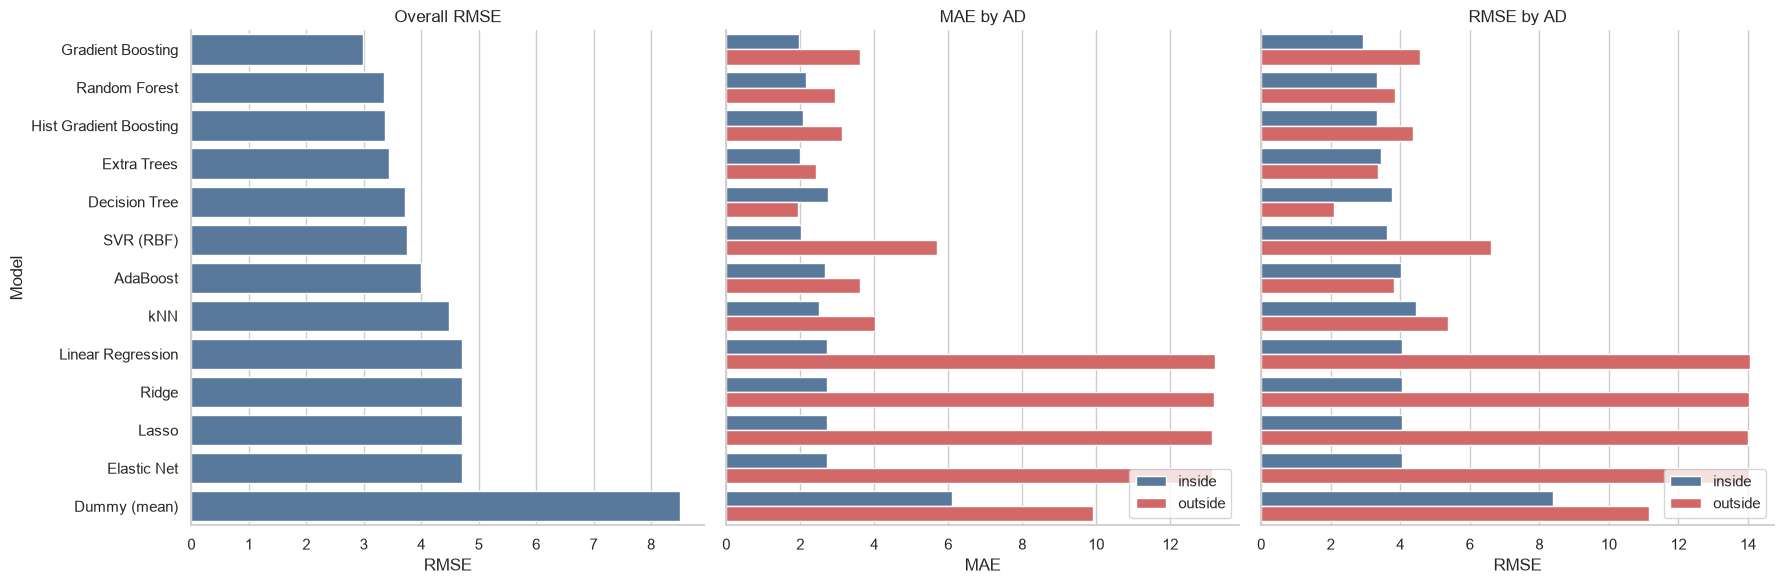

In [7]:
model_order = model_ad_comparison["model"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.barplot(
    data=model_ad_comparison,
    x="RMSE",
    y="model",
    order=model_order,
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Overall RMSE")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("Model")

sns.barplot(
    data=ad_summary,
    x="MAE",
    y="model",
    hue="AD",
    order=model_order,
    hue_order=["inside", "outside"],
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    ax=axes[1],
)
axes[1].set_title("MAE by AD")
axes[1].set_xlabel("MAE")
axes[1].set_ylabel("")

sns.barplot(
    data=ad_summary,
    x="RMSE",
    y="model",
    hue="AD",
    order=model_order,
    hue_order=["inside", "outside"],
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    ax=axes[2],
)
axes[2].set_title("RMSE by AD")
axes[2].set_xlabel("RMSE")
axes[2].set_ylabel("")

for ax in axes[1:]:
    ax.legend(title=None, loc="lower right")

plt.tight_layout()
plt.show()


## 8. kNN 平均距離と誤差の関係をモデルごとに見る

全モデルについて、横軸にAD判定で使ったkNN平均距離、縦軸に絶対誤差を取ります。赤い破線より右側がAD外です。


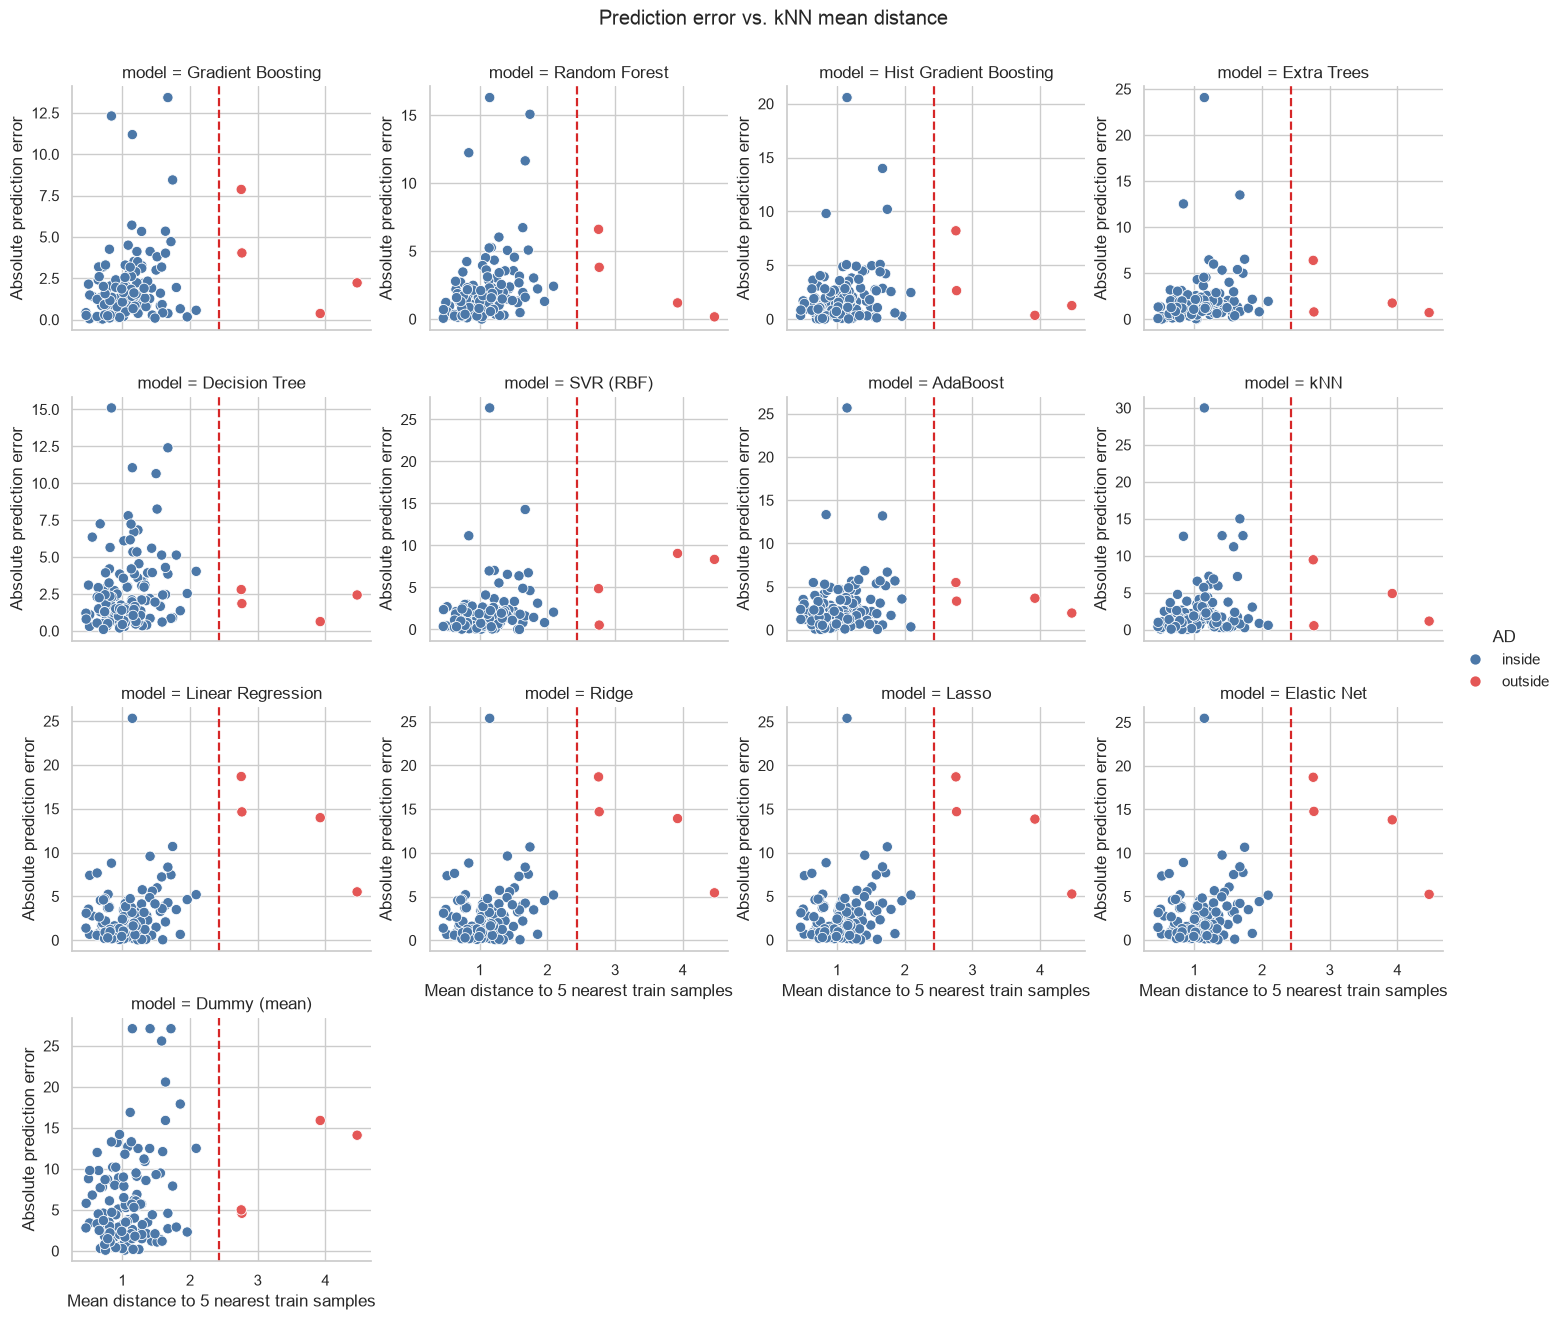

In [8]:
plot_model_order = model_scores["model"].tolist()
plot_results = all_model_results.copy()

facet = sns.relplot(
    data=plot_results,
    x="knn_mean_distance",
    y="abs_error",
    hue="AD",
    col="model",
    col_order=plot_model_order,
    col_wrap=4,
    kind="scatter",
    height=3.2,
    aspect=1.15,
    facet_kws={"sharey": False},
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    s=55,
)

for ax in facet.axes.flat:
    ax.axvline(ad_threshold, color="#D62728", linestyle="--", linewidth=1.6)
    ax.set_xlabel("Mean distance to 5 nearest train samples")
    ax.set_ylabel("Absolute prediction error")

facet.fig.suptitle("Prediction error vs. kNN mean distance", y=1.03)
plt.show()


## 9. 実測値と予測値を AD 内外で色分けする

同じAD外サンプルでも、モデルによって予測値の外れ方が違います。点が点線に近いほど予測が良いです。


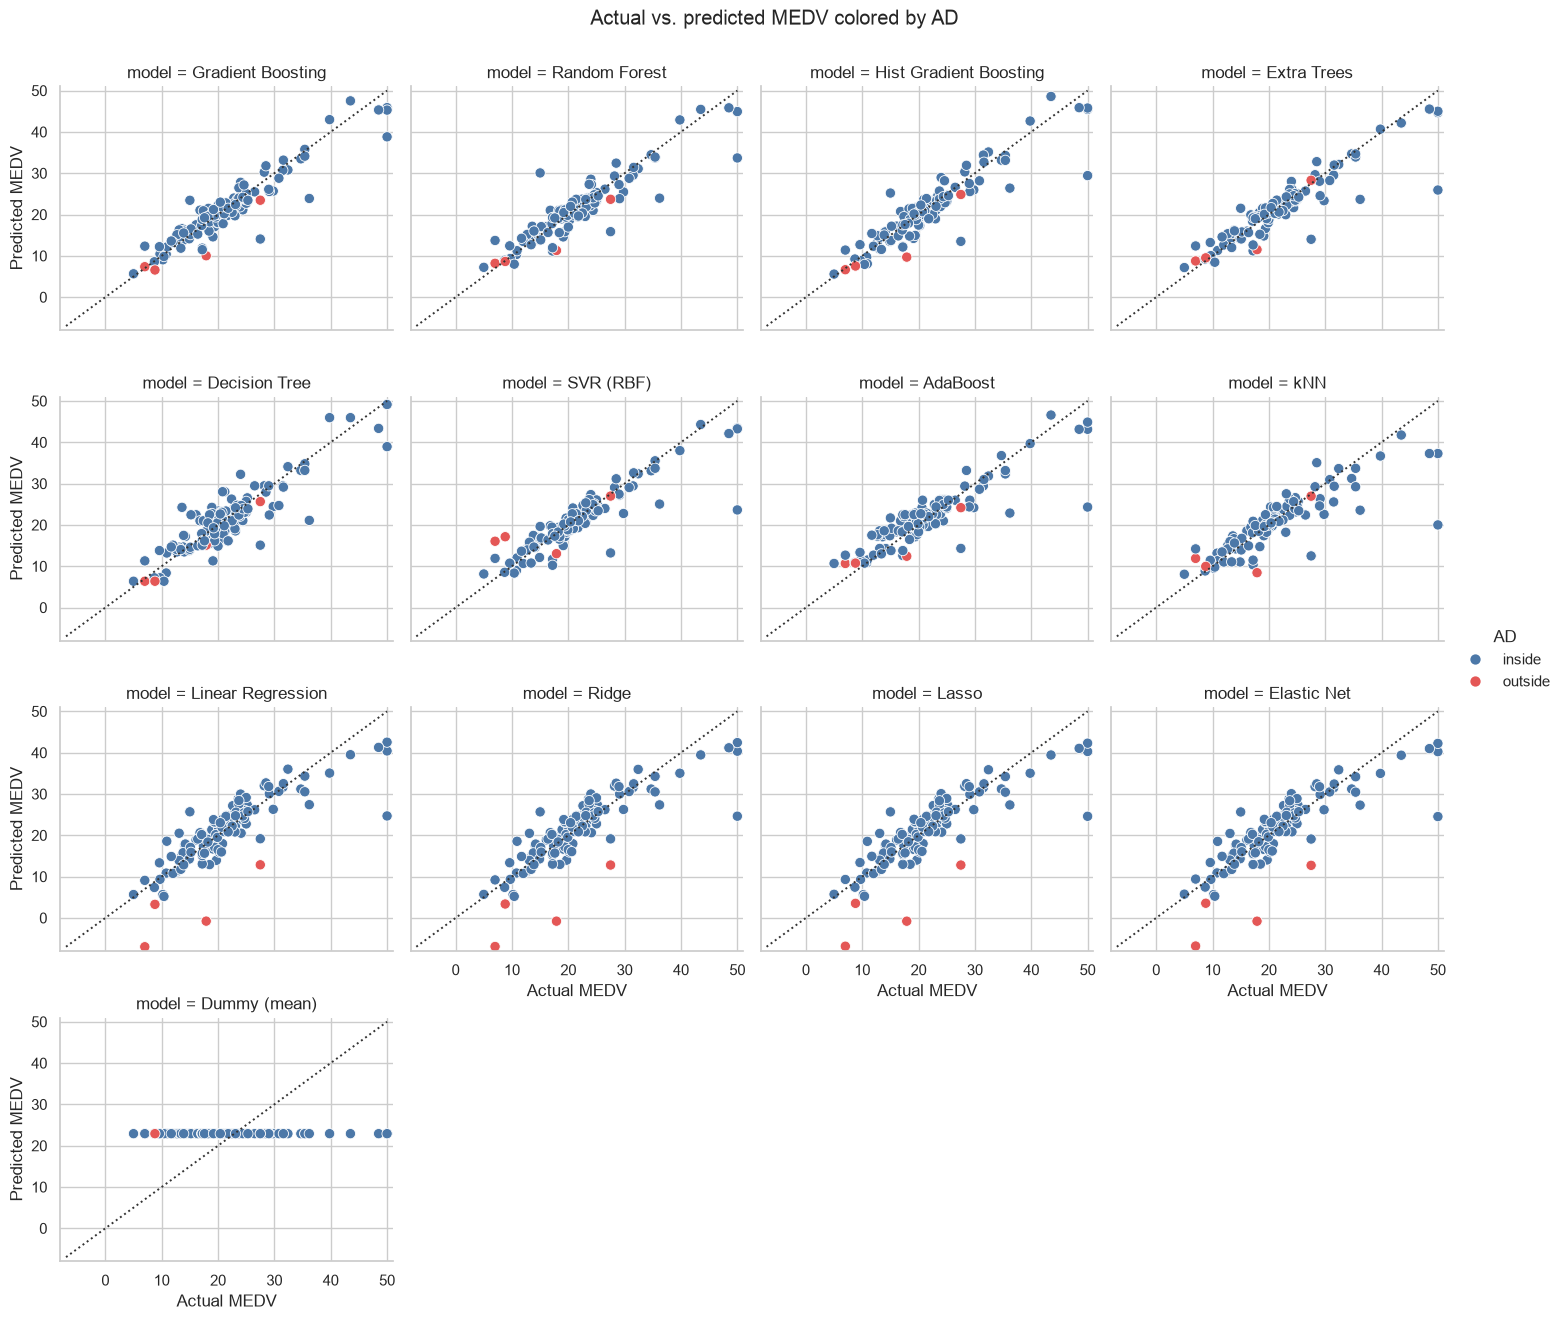

In [9]:
facet = sns.relplot(
    data=plot_results,
    x="actual_MEDV",
    y="predicted_MEDV",
    hue="AD",
    col="model",
    col_order=plot_model_order,
    col_wrap=4,
    kind="scatter",
    height=3.2,
    aspect=1.15,
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    s=55,
)

min_value = min(plot_results["actual_MEDV"].min(), plot_results["predicted_MEDV"].min())
max_value = max(plot_results["actual_MEDV"].max(), plot_results["predicted_MEDV"].max())

for ax in facet.axes.flat:
    ax.plot([min_value, max_value], [min_value, max_value], color="#333333", linestyle=":", linewidth=1.4)
    ax.set_xlim(min_value - 1, max_value + 1)
    ax.set_ylim(min_value - 1, max_value + 1)
    ax.set_xlabel("Actual MEDV")
    ax.set_ylabel("Predicted MEDV")

facet.fig.suptitle("Actual vs. predicted MEDV colored by AD", y=1.03)
plt.show()


## 10. AD 内・AD 外での順位を比較する

全体RMSEで最良のモデルが、AD外でも最良とは限りません。AD外サンプル数が少ない点に注意しつつ、順位の変化を確認します。


In [10]:
rank_table = model_ad_comparison.copy()
rank_table["rank_overall_RMSE"] = rank_table["RMSE"].rank(method="min", ascending=True).astype(int)
rank_table["rank_inside_RMSE"] = rank_table["RMSE_inside"].rank(method="min", ascending=True).astype(int)
rank_table["rank_outside_RMSE"] = rank_table["RMSE_outside"].rank(method="min", ascending=True).astype(int)

rank_columns = [
    "model",
    "rank_overall_RMSE",
    "rank_inside_RMSE",
    "rank_outside_RMSE",
    "RMSE",
    "RMSE_inside",
    "RMSE_outside",
    "MAE_outside_minus_inside",
]

display(
    rank_table[rank_columns]
    .sort_values(["rank_outside_RMSE", "rank_overall_RMSE"])
    .round(
        {
            "RMSE": 3,
            "RMSE_inside": 3,
            "RMSE_outside": 3,
            "MAE_outside_minus_inside": 3,
        }
    )
)


,model,rank_overall_RMSE,rank_inside_RMSE,rank_outside_RMSE,RMSE,RMSE_inside,RMSE_outside,MAE_outside_minus_inside
4,Decision Tree,5,6,1,3.709,3.750,2.097,-0.815
3,Extra Trees,4,4,2,3.447,3.449,3.358,0.424
6,AdaBoost,7,7,3,4.002,4.008,3.818,0.945
1,Random Forest,2,3,4,3.359,3.341,3.859,0.791
2,Hist Gradient Boosting,3,2,5,3.376,3.339,4.361,1.047
0,Gradient Boosting,1,1,6,2.993,2.927,4.565,1.650
7,kNN,8,12,7,4.488,4.456,5.365,1.506
5,SVR (RBF),6,5,8,3.755,3.623,6.620,3.678
12,Dummy (mean),13,13,9,8.501,8.400,11.161,3.801
10,Lasso,11,10,10,4.703,4.057,14.008,10.400


## 11. AD 外サンプルだけを詳しく見る

AD 外サンプルは全モデルで同じです。ここでは、AD 外サンプルごとに各モデルの絶対誤差を横並びにして、どのサンプルが難しいかを見ます。


In [11]:
outside_sample_ids = ad_info.query("AD == 'outside'").index.tolist()

if len(outside_sample_ids) == 0:
    print("このHold-Out分割ではAD外サンプルがありません。")
else:
    outside_sample_info = ad_info.loc[outside_sample_ids].sort_values("knn_mean_distance", ascending=False)
    display(outside_sample_info.round(3))

    outside_errors = all_model_results[all_model_results["AD"] == "outside"].pivot(
        index="sample_id",
        columns="model",
        values="abs_error",
    )
    outside_errors["mean_abs_error_across_models"] = outside_errors.mean(axis=1)
    outside_errors = outside_errors.sort_values("mean_abs_error_across_models", ascending=False)
    display(outside_errors.round(3))


,knn_mean_distance,AD
sample_419,4.468,outside
sample_415,3.924,outside
sample_366,2.767,outside
sample_413,2.757,outside


model,AdaBoost,Decision Tree,Dummy (mean),Elastic Net,Extra Trees,Gradient Boosting,Hist Gradient Boosting,Lasso,Linear Regression,Random Forest,Ridge,SVR (RBF),kNN,mean_abs_error_across_models
sample_id,,,,,,,,,,,,,,
sample_413,5.478,2.800,5.008,18.690,6.392,7.873,8.207,18.688,18.675,6.605,18.681,4.858,9.46,10.109
sample_415,3.667,0.633,15.908,13.802,1.758,0.372,0.356,13.849,13.979,1.192,13.918,9.049,4.90,7.183
sample_366,3.326,1.850,4.592,14.770,0.794,4.033,2.649,14.699,14.640,3.809,14.696,0.519,0.54,6.224
sample_419,1.951,2.433,14.108,5.242,0.720,2.225,1.263,5.268,5.516,0.163,5.433,8.340,1.16,4.140


## 12. モデル別の大きな誤差を確認する

各モデルについて、絶対誤差が大きいテストサンプル上位3件を表示します。AD外が多く含まれるか、AD内でも大きく外す点があるかを確認します。


In [12]:
worst_by_model = (
    all_model_results
    .sort_values(["model", "abs_error"], ascending=[True, False])
    .groupby("model", group_keys=False)
    .head(3)
)

show_columns = [
    "model",
    "sample_id",
    "AD",
    "actual_MEDV",
    "predicted_MEDV",
    "abs_error",
    "knn_mean_distance",
]

display(
    worst_by_model[show_columns]
    .sort_values(["model", "abs_error"], ascending=[True, False])
    .round(3)
)


,model,sample_id,AD,actual_MEDV,predicted_MEDV,abs_error,knn_mean_distance
1620,AdaBoost,sample_372,inside,50.0,24.326,25.674,1.149
1637,AdaBoost,sample_182,inside,36.2,22.868,13.332,0.841
1635,AdaBoost,sample_410,inside,27.5,14.313,13.187,1.674
1002,Decision Tree,sample_182,inside,36.2,21.100,15.100,0.841
1000,Decision Tree,sample_410,inside,27.5,15.100,12.400,1.674
985,Decision Tree,sample_372,inside,50.0,38.950,11.050,1.149
18,Dummy (mean),sample_196,inside,50.0,22.908,27.092,1.411
42,Dummy (mean),sample_205,inside,50.0,22.908,27.092,1.720
96,Dummy (mean),sample_372,inside,50.0,22.908,27.092,1.149
604,Elastic Net,sample_372,inside,50.0,24.538,25.462,1.149


## Exercises

1. `AD_PERCENTILE = 90` に変更して、3章以降を再実行してください。AD外サンプル数とAD外RMSEはどう変わりますか。
2. `AD_PERCENTILE = 99` に変更した場合も確認してください。AD外サンプルが少ないと、AD外の平均誤差は安定して読めるでしょうか。
3. `K_NEIGHBORS = 3` または `K_NEIGHBORS = 10` に変更し、AD外に選ばれるサンプルがどう変わるか確認してください。
4. 下のセルで、しきい値パーセンタイルだけを変えた比較表を作れます。


In [13]:
def compare_ad_percentile(percentile: float) -> pd.DataFrame:
    threshold = np.percentile(train_knn_mean_distance, percentile)
    labels_by_sample = pd.Series(
        np.where(test_knn_mean_distance <= threshold, "inside", "outside"),
        index=y_test.index,
        name="AD",
    )

    tmp_results = all_model_results.copy()
    tmp_results["AD"] = tmp_results["sample_id"].map(labels_by_sample)
    _, tmp_comparison = summarize_by_ad(tmp_results, model_scores)
    return tmp_comparison[
        [
            "model",
            "n_inside",
            "n_outside",
            "MAE_inside",
            "MAE_outside",
            "RMSE_inside",
            "RMSE_outside",
            "MAE_outside_minus_inside",
        ]
    ].sort_values("RMSE_outside", ascending=True)

# 例: 90パーセンタイル基準でAD外を広めに取った場合
comparison_90 = compare_ad_percentile(90)
display(
    comparison_90.round(
        {
            "MAE_inside": 3,
            "MAE_outside": 3,
            "RMSE_inside": 3,
            "RMSE_outside": 3,
            "MAE_outside_minus_inside": 3,
        }
    )
)


,model,n_inside,n_outside,MAE_inside,MAE_outside,RMSE_inside,RMSE_outside,MAE_outside_minus_inside
4,Decision Tree,121.0,6.0,2.735,2.381,3.756,2.591,-0.354
3,Extra Trees,121.0,6.0,2.003,2.071,3.472,2.874,0.068
1,Random Forest,121.0,6.0,2.155,2.580,3.360,3.344,0.425
6,AdaBoost,121.0,6.0,2.672,3.058,4.027,3.445,0.386
2,Hist Gradient Boosting,121.0,6.0,2.083,2.537,3.359,3.703,0.454
0,Gradient Boosting,121.0,6.0,2.002,2.539,2.951,3.735,0.537
7,kNN,121.0,6.0,2.539,2.920,4.492,4.401,0.381
5,SVR (RBF),121.0,6.0,2.023,4.273,3.648,5.481,2.250
12,Dummy (mean),121.0,6.0,6.081,9.072,8.390,10.488,2.990
11,Elastic Net,121.0,6.0,2.692,10.343,4.046,11.771,7.651


## まとめ

- 既存ノートブックでは、RMSE最小モデルの予測結果だけを使ってAD内外の誤差を見ていた。
- このノートブックでは、同じAD判定を全モデルの予測結果に付与し、AD内・AD外のMAE/RMSEを比較した。
- kNN距離によるAD判定は特徴量空間から決まるため、モデルを変えてもAD内外ラベルは同じになる。
- 比較すべき点は、各モデルがAD外サンプルでどれだけ誤差を増やすか、また全体性能の順位とAD外性能の順位が一致するかである。
- AD外サンプル数が少ない場合、AD外の平均誤差は1点の影響を強く受けるため、表だけでなく個別サンプルも確認する。
